# Lab: Regression Trees

*This notebook demonstrates the process of building, evaluating, and interpreting a Regression Tree model, structured according to a formal data science [methodology](../../../05_methodology/)*.

---

## Stage 1: Business Understanding

Let's start by understanding the problem from a business perspective.

*   **Scenario:** We are data scientists working with data from the NYC Taxi and Limousine Commission (TLC). The dataset contains details about individual taxi trips.
*   **Business Objective:** To build a model that can predict the `tip_amount` for a taxi ride based on other trip details (like distance, cost, and passenger count). This could be used to understand factors that influence tipping, analyze driver earnings, or even build features for driver-facing applications.

---

## Stage 2: Analytic Approach

With the business problem defined, we select an analytic approach:

*   **Problem Framing:** The business objective is to predict a specific numerical quantity (`tip_amount`), which is a continuous variable. This is a **Regression** problem.
*   **Candidate Model:** Because this is a lab notebook for the **Regression Tree** lecture, we will only choose `DecisionTreeRegressor` as our candidate model. It is highly interpretable, can capture non-linear relationships between features, and does not require extensive feature scaling.
*   **Evaluation Metrics:** We will evaluate the model's performance using standard regression metrics:
    *   **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values. Lower is better.
    *   **R-squared (R²):** Represents the proportion of the variance in the target variable that is predictable from the features. A score closer to 1.0 indicates a better fit.

---

## Stage 3: Data Requirements

To build our model, we need trip data including the fare amount, trip distance, payment type, and other related features. Instead of specifying all the candidate predictors with the help of a domain expert, we'll let the data speak for itself during the Data Understanding phase.

---

## Stage 4: Data Collection

The data has already been collected and is available in a CSV file from a public URL. Let's import the necessary libraries and load the data into a pandas DataFrame.

In [41]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Configurations
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)

# Helper function for clean output
def rich_print(title, func, *args, **kwargs):
    """Prints a formatted title and the output of a function."""
    print(f"=============== {title} ===============")
    func(*args, **kwargs)
    print("="*(70 - len(title)))
    print()

In [42]:
# Load the data from the URL
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
try:
    df = pd.read_csv(url)
    print("Data loaded successfully from the URL into a DataFrame.")
except Exception as e:
    print(f"Error loading data: {e}")

Data loaded successfully from the URL into a DataFrame.


### Initial Data Ingestion and Verification
Let's perform a quick, high-level check to ensure the collected data is readable and appears correct.

In [34]:
# Display a sample from the data
df.sample(5)

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
8747,2,2,19.56,2,1,132,238,1,70.0,0.5,6.94,1,16.54
24308,2,3,19.15,2,1,132,143,1,70.0,0.5,0.00,1,14.80
33804,2,1,17.65,2,1,132,230,1,70.0,0.5,6.94,1,16.54
31888,2,3,18.00,2,1,132,68,1,70.0,0.5,6.94,1,16.19
28485,2,3,20.20,2,1,132,164,1,70.0,0.5,6.94,1,16.19


In [35]:
# Get the general information 
rich_print("General Information", df.info)

=============== General Information ===============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB



> 📊 **Data Collection Report:**
>
> *   The data loads without errors.
> *   The number of rows (**41,202**) and columns (13) seem reasonable.
> *   All columns have been loaded with numerical data types (`int64` or `float64`), and there are no missing values.
> *   By glancing at a sample and the data types, we can confirm that **the data is ready for initial analysis**.



---

## Stage 5: Data Understanding
Now we perform Exploratory Data Analysis to understand the data's characteristics and inform our modeling strategy. Let's start by examining the linear correlation of the features with our target variable, `tip_amount`.

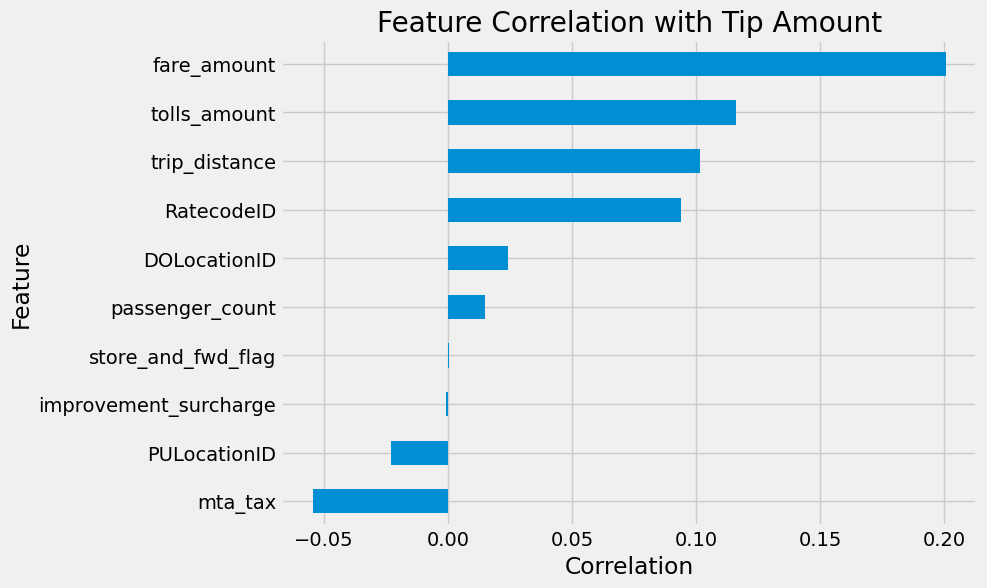

In [64]:
# Calculate and plot correlations with the target variable
plt.figure(figsize=(8, 6))
df.corr()['tip_amount'].drop('tip_amount').sort_values().plot(kind='barh')
plt.title('Feature Correlation with Tip Amount')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

> 📊 **Data Understanding Report:**
>
> *   The `fare_amount` has the strongest positive correlation with `tip_amount`. This makes intuitive sense—larger fares typically result in larger tips.
> *   However, even this strongest correlation is only around **0.2**, which is considered weak. The other features have even weaker linear relationships with the target.
> *   **Key Insight:** This lack of strong linear correlation is a key finding. It suggests that a simple linear model would likely perform poorly. This strengthens our decision to use a **Regression Tree**, which is a non-linear model capable of capturing more complex patterns and interactions between features that a correlation matrix cannot reveal.

---

## Stage 6: Data Preparation
This stage involves all activities to construct the final dataset for modeling. Because Decision Trees are robust to irrelevant featurers, we will proceed by including all features for the initial model. The tree algorithm itself will perform a type of feature selection.

### 6.1. Final Dataset Split
First, we separate the data into the feature matrix (`X`) and the target vector (`y`). Then we perform the train-test split *before* any scaling to prevent data leakage.

In [65]:
# X containts our independent variables
X = df.drop('tip_amount', axis=1)

# y contains our dependent variable
y = df['tip_amount']

# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 6.2. Feature Scaling
While Decision Trees are not sensitive to feature scaling, it's still a good practice, especially if we wanted to compare this model to others. We will use `StandardScaler` to standardize the features.

**Best Practice:** We `fit` the scaler **only on the training data** and then use that same scaler to `transform` both the training and test data.

In [66]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to tranform the test data
X_test_scaled = scaler.transform(X_test)


---

## Stage 7: Modeling

With the data prepared, we can now build and train our Regression Tree model.

We'll create an instance of `DecisionTreeRegressor`. Two key parameters we'll set are:
* `criterion='squared_error'`: This tells the tree to use **Mean Squared Error** as its splitting criterion, which is standard for regression.
* `max_depth=8`: This is a **pre-pruning** technique to prevent the tree from becoming too complex and overfitting

In [68]:
# Create and train the Decision Tree Regression model
dt_reg = DecisionTreeRegressor(criterion='squared_error', max_depth=8, random_state=35)
dt_reg.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,35
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0



---

## Stage 8: Evaluation
In this stage, we evaluate the final model on the held-back test set to get an unbiased estimate of its performance.

In [73]:
# Make predictions on the scaled test set
y_pred = dt_reg.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=============== Model Evaluation ===============")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R-squared (R²): {r2:.3f}")
print("="*48)

=============== Model Evaluation ===============
Mean Squared Error (MSE): 25.202
R-squared (R²): 0.002
